## Import Libraries

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from galform_analysis.config import get_base_dir
from galform_analysis.analysis import (
    process_efficiency_redshifts,
    save_efficiency_data,
    find_peak_efficiency
)

project_root = Path.cwd().parent
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

base_dir = get_base_dir()

## Configure Analysis Parameters

In [2]:
redshifts = ['iz82']#, 'iz100']#, 'iz120', 'iz142', 'iz176']

# Halo mass bins (log10 M_sun)
mass_bins = np.arange(10.0, 15.5, 0.2)

print(f"Base directory: {base_dir}")
print(f"Redshifts: {redshifts}")
print(f"Mass bins: {len(mass_bins)-1} bins from {mass_bins[0]} to {mass_bins[-1]}")

Base directory: /cosma5/data/durham/dc-hick2/Galform_Out/L800/gp14
Redshifts: ['iz82']
Mass bins: 27 bins from 10.0 to 15.39999999999998


## Process Redshifts

In [3]:
results = process_efficiency_redshifts(redshifts, mass_bins, base_dir=base_dir, verbose=True)


 Processing iz82 (z=6.01)...
Loaded 71523333 galaxies at z≈6.01
Efficiency computed for 14 mass bins

 Successfully processed 1 redshifts


## Plot Galaxy Formation Efficiency

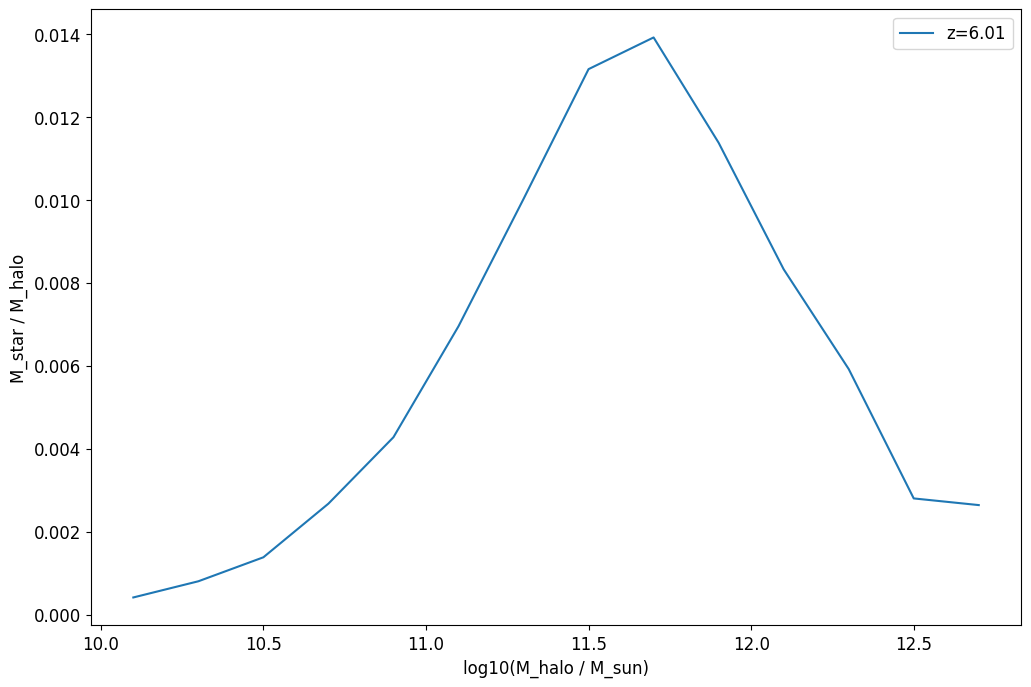

In [11]:
# Plot efficiency vs mass for each processed redshift
for result in results:
    z = result.get('z')
    label = f"z={z:.2f}" if z is not None else "z=unknown"
    plt.plot(result['centers'], result['eta_med'], label=label)

plt.xlabel(r"log10(M_halo / M_sun)")
plt.ylabel(r"M_star / M_halo")
plt.legend()
plt.show()

## Find Peak Efficiency

Identify where star formation is most efficient for each redshift.

In [12]:
# Find and display peak efficiency for each redshift
peak_df = find_peak_efficiency(results, redshifts)
print("\nPeak Galaxy Formation Efficiency:")
print(peak_df.to_string(index=False))
print("\nPeak efficiency occurs at log(M_halo) ≈ {:.2f} across most redshifts".format(
    peak_df['peak_mass'].median()
))


Peak Galaxy Formation Efficiency:
redshift_name  redshift  peak_mass  peak_efficiency
         iz82    6.0108       11.7          0.01392

Peak efficiency occurs at log(M_halo) ≈ 11.70 across most redshifts
